In [1]:
import sys

!{sys.executable} -m pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 827.2 kB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 1.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [scikit-learn] [scikit-learn]


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

In [5]:
p_malware = 0.005
p_flagged_given_malware = 0.95
p_flagged_given_clean = 0.03

In [6]:
p_flagged = (p_flagged_given_malware * p_malware) + (p_flagged_given_clean * (1 - p_malware))
p_malware_given_flagged = (p_flagged_given_malware * p_malware) / p_flagged

print(f'P(flagged) = {p_flagged:.5f}')
print(f'P(malware | flagged) = {p_malware_given_flagged:.4f}')

P(flagged) = 0.03460
P(malware | flagged) = 0.1373


In [7]:
n_files = 1_000_000
true_flags = n_files * p_malware * p_flagged_given_malware
false_flags = n_files * (1 - p_malware) * p_flagged_given_clean

print(f'True flags:  {true_flags:,.0f}')
print(f'False flags: {false_flags:,.0f}')
print(f'Ratio:       {true_flags / (true_flags + false_flags):.4f}')

True flags:  4,750
False flags: 29,850
Ratio:       0.1373


In [8]:
np.random.seed(42)
n_sim = 250_000
is_malware = np.random.rand(n_sim) < p_malware

flag_probs = np.where(is_malware, p_flagged_given_malware, p_flagged_given_clean)
flagged = np.random.rand(n_sim) < flag_probs

simulated_posterior = is_malware[flagged].mean()
print(f'Simulated P(malware | flagged) = {simulated_posterior:.4f}')

Simulated P(malware | flagged) = 0.1386


In [9]:
alpha0, beta0 = 2, 8
clicks, ignores = 6, 18

In [10]:
n = clicks + ignores
mle = clicks / n
posterior_alpha = alpha0 + clicks
posterior_beta = beta0 + ignores
posterior_mean = posterior_alpha / (posterior_alpha + posterior_beta)
map_estimate = (posterior_alpha - 1) / (posterior_alpha + posterior_beta - 2)

print(f'MLE             = {mle:.3f}')
print(f'Posterior        = Beta({posterior_alpha}, {posterior_beta})')
print(f'Posterior mean   = {posterior_mean:.3f}')
print(f'MAP              = {map_estimate:.3f}')

MLE             = 0.250
Posterior        = Beta(8, 26)
Posterior mean   = 0.235
MAP              = 0.219


In [11]:
zero_clicks, zero_ignores = 0, 12

zero_mle = zero_clicks / (zero_clicks + zero_ignores)
zero_posterior_mean = (alpha0 + zero_clicks) / (alpha0 + zero_clicks + beta0 + zero_ignores)

print(f'Zero-click MLE            = {zero_mle:.3f}')
print(f'Zero-click posterior mean = {zero_posterior_mean:.3f}')

Zero-click MLE            = 0.000
Zero-click posterior mean = 0.091


In [12]:
np.random.seed(42)
x = np.sort(np.random.uniform(0, 1, 40))
y = np.sin(2 * np.pi * x) + 0.25 * np.random.normal(size=40)
X = x.reshape(-1, 1)
x_grid = np.linspace(0, 1, 300).reshape(-1, 1)

In [13]:
degrees = np.arange(1, 13)
train_mse, cv_means, cv_se = [], [], []
cv = KFold(n_splits=5, shuffle=True, random_state=42)

for degree in degrees:
    model = Pipeline([
        ('poly', PolynomialFeatures(degree=degree)),
        ('linear', LinearRegression()),
    ])

    model.fit(X, y)
    y_pred = model.predict(X)
    train_mse.append(mean_squared_error(y, y_pred))

    fold_scores = -cross_val_score(model, X, y, scoring='neg_mean_squared_error', cv=cv)
    cv_means.append(np.mean(fold_scores))
    cv_se.append(np.std(fold_scores, ddof=1) / np.sqrt(len(fold_scores)))

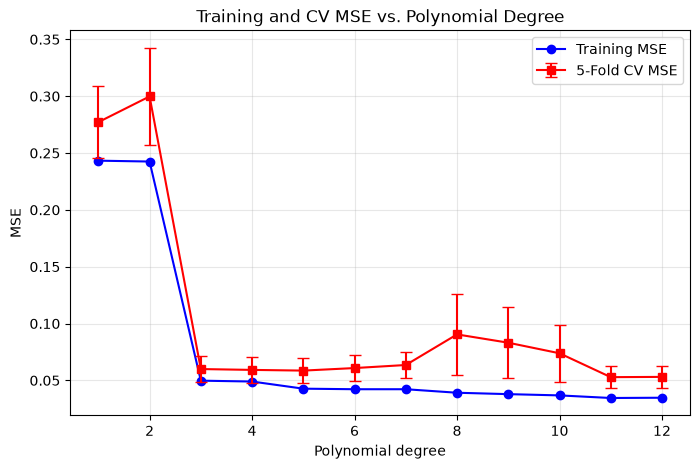

In [14]:
plt.figure(figsize=(8, 5))
plt.plot(degrees, train_mse, label='Training MSE', color='blue', marker='o')
plt.errorbar(degrees, cv_means, yerr=cv_se, label='5-Fold CV MSE', color='red', marker='s', capsize=4)
plt.xlabel('Polynomial degree')
plt.ylabel('MSE')
plt.title('Training and CV MSE vs. Polynomial Degree')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [15]:
selected_index = np.argmin(cv_means)
selected_degree = degrees[selected_index]

print(f'Selected degree: {selected_degree}')
print(f'CV MSE: {cv_means[selected_index]:.4f} +/- {cv_se[selected_index]:.4f}')

Selected degree: 11
CV MSE: 0.0528 +/- 0.0097


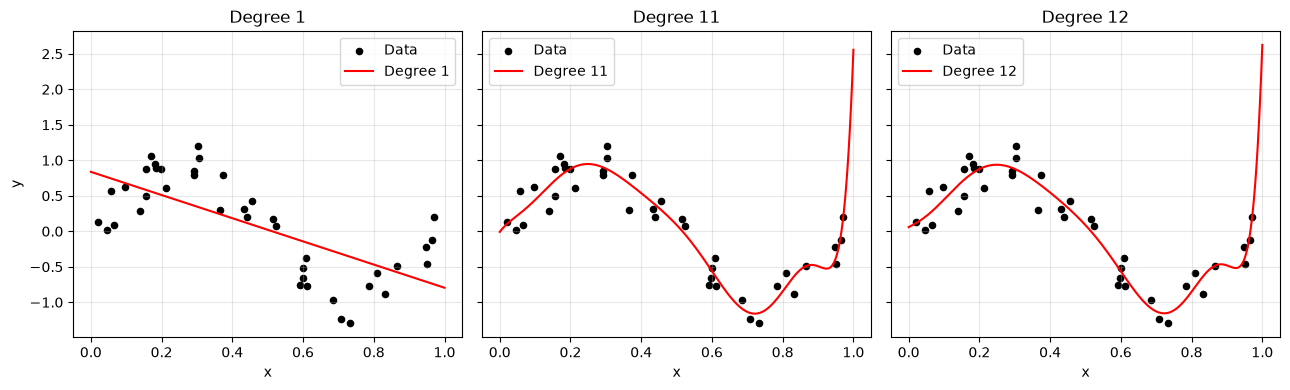

In [16]:
plot_degrees = [1, selected_degree, 12]
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)

for ax, degree in zip(axes, plot_degrees):
    model = Pipeline([
        ('poly', PolynomialFeatures(degree=degree)),
        ('linear', LinearRegression()),
    ])
    model.fit(X, y)
    y_grid = model.predict(x_grid)
    
    ax.scatter(X, y, color='black', label='Data', s=20)
    ax.plot(x_grid, y_grid, color='red', label=f'Degree {degree}')
    ax.set_title(f'Degree {degree}')
    ax.set_xlabel('x')
    ax.grid(alpha=0.3)
    ax.legend()

axes[0].set_ylabel('y')
plt.tight_layout()
plt.show()